In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
C:\Users\SHARMA PRIYANSHU\OneDrive\Desktop\Unified Mentor Projects\Project 1 Finance Analytics\notebooks

Files/folders here:
['.ipynb_checkpoints', '.virtual_documents', '01_data_understanding_eda.ipynb', 'catboost_info']


In [7]:
df = pd.read_csv("../data/raw/European_Bank.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
print(f"Rows  :{df.shape[0]: ,}")
print(f"Columns  :{df.shape[1]:}")

Rows  : 10,000
Columns  :14


In [9]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
missing = df.isnull().sum()
print("Missing values per column : ")
print(missing)
print("\nTotal missing values:", missing.sum())

Missing values per column : 
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing values: 0


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
for col in df.columns:
    print(f"{col:20} → {df[col].nunique():,} unique values")

Year                 → 1 unique values
CustomerId           → 10,000 unique values
Surname              → 2,932 unique values
CreditScore          → 460 unique values
Geography            → 3 unique values
Gender               → 2 unique values
Age                  → 70 unique values
Tenure               → 11 unique values
Balance              → 6,382 unique values
NumOfProducts        → 4 unique values
HasCrCard            → 2 unique values
IsActiveMember       → 2 unique values
EstimatedSalary      → 9,999 unique values
Exited               → 2 unique values


In [14]:
print("Year values:")
print(df["Year"].value_counts())

print("\nExited distribution:")
print(df["Exited"].value_counts())

Year values:
Year
2025    10000
Name: count, dtype: int64

Exited distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [15]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [16]:
print("Tenure:")
print(df["Tenure"].value_counts().sort_index())

print("\nNumOfProducts:")
print(df["NumOfProducts"].value_counts().sort_index())

print("\nHasCrCard:")
print(df["HasCrCard"].value_counts().sort_index())

print("\nIsActiveMember:")
print(df["IsActiveMember"].value_counts().sort_index())

Tenure:
Tenure
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: count, dtype: int64

NumOfProducts:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

HasCrCard:
HasCrCard
0    2945
1    7055
Name: count, dtype: int64

IsActiveMember:
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [18]:
print("Customers with zero balance:")
print((df["Balance"] == 0).sum())

print("\nPercentage with zero balance:")
print(f"{(df['Balance'] == 0).mean() * 100:.2f}%")

Customers with zero balance:
3617

Percentage with zero balance:
36.17%


In [19]:
balance_churn = pd.crosstab(
    df["Balance"] == 0,
    df["Exited"],
    normalize="index"
) * 100

balance_churn

Exited,0,1
Balance,,
False,75.920414,24.079586
True,86.176389,13.823611


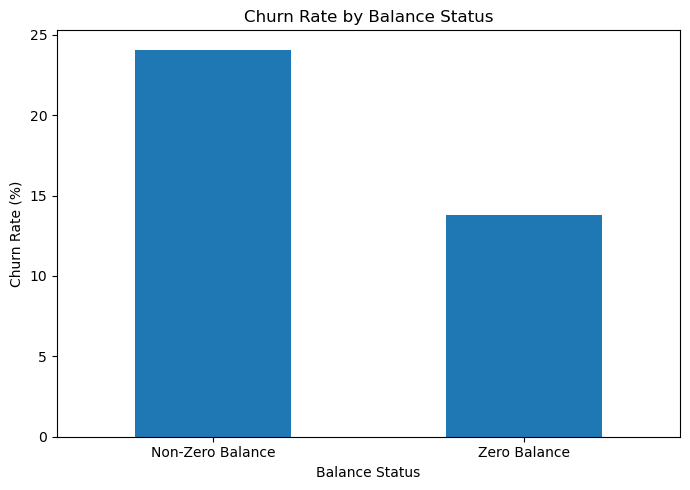

In [20]:
balance_churn_plot = (
    df.assign(Balance_Status=np.where(df["Balance"] == 0, "Zero Balance", "Non-Zero Balance"))
      .groupby("Balance_Status")["Exited"]
      .mean()
      .mul(100)
)

balance_churn_plot.plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Balance Status")
plt.xlabel("Balance Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
geography_churn = pd.crosstab(
    df["Geography"],
    df["Exited"],
    margins=True
)

geography_churn

Exited,0,1,All
Geography,,,
France,4204,810,5014
Germany,1695,814,2509
Spain,2064,413,2477
All,7963,2037,10000


In [22]:
geography_churn_rate = (
    df.groupby("Geography")["Exited"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

geography_churn_rate

Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64

In [23]:
gender_churn = (
    df.groupby("Gender")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

gender_churn

Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

In [24]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

age_group_churn = (
    df.groupby("Age_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

age_group_churn

Age_Group
18-25     7.53
26-35     8.50
36-45    19.62
46-55    50.57
56-65    48.32
66+      13.26
Name: Exited, dtype: float64

In [25]:
df["Age"].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [26]:
age_group_counts = df["Age_Group"].value_counts().sort_index()

age_group_counts

Age_Group
18-25     611
26-35    3542
36-45    3736
46-55    1311
56-65     536
66+       264
Name: count, dtype: int64

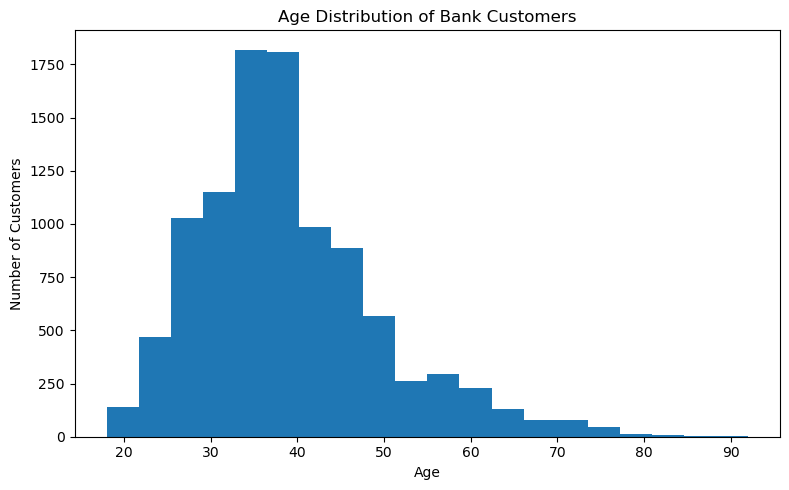

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution of Bank Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [28]:
tenure_churn = (
    df.groupby("Tenure")["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

tenure_churn

Tenure
0     23.00
1     22.42
2     19.18
3     21.11
4     20.53
5     20.65
6     20.27
7     17.22
8     19.22
9     21.65
10    20.61
Name: Exited, dtype: float64

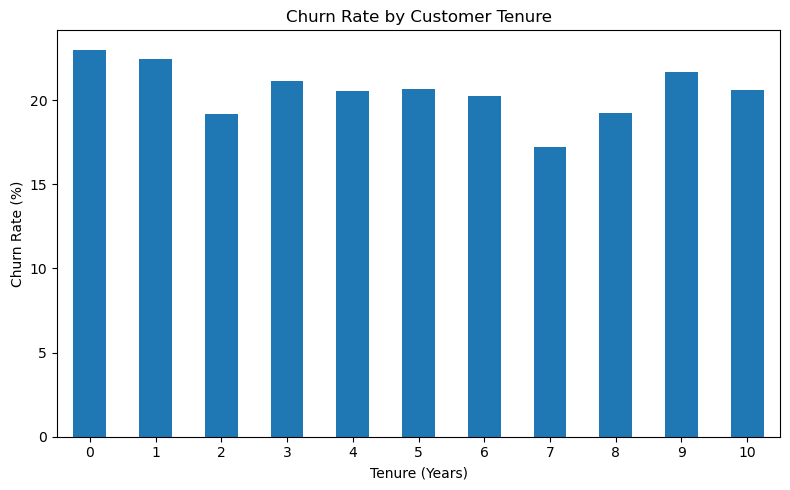

In [29]:
tenure_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
product_churn = (
    df.groupby("NumOfProducts")["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .sort_index()
)

product_churn

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

In [31]:
product_churn_counts = pd.crosstab(
    df["NumOfProducts"],
    df["Exited"]
)

product_churn_counts

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


In [32]:
credit_card_churn = (
    df.groupby("HasCrCard")["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

credit_card_churn

HasCrCard
0    20.81
1    20.18
Name: Exited, dtype: float64

In [33]:
active_member_churn = (
    df.groupby("IsActiveMember")["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

active_member_churn

IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64

In [34]:
df["CreditScore_Group"] = pd.cut(
    df["CreditScore"],
    bins=[349, 579, 669, 739, 799, 850],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

credit_score_churn = (
    df.groupby("CreditScore_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

credit_score_churn

CreditScore_Group
Poor         22.02
Fair         20.56
Good         18.62
Very Good    20.59
Excellent    19.54
Name: Exited, dtype: float64

In [35]:
df["Salary_Group"] = pd.qcut(
    df["EstimatedSalary"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

salary_churn = (
    df.groupby("Salary_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

salary_churn

Salary_Group
Low            20.00
Medium-Low     19.80
Medium-High    20.12
High           21.56
Name: Exited, dtype: float64

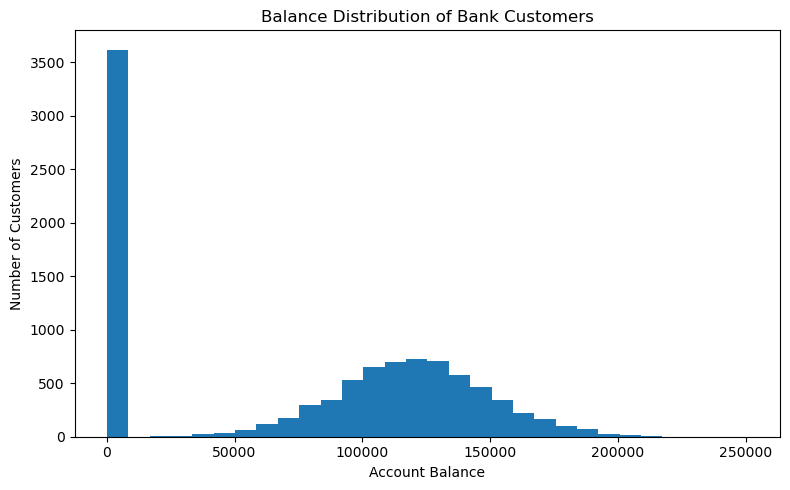

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(df["Balance"], bins=30)

plt.title("Balance Distribution of Bank Customers")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [37]:
print("Year unique values:")
print(df["Year"].unique())

print("\nCustomerId unique values:")
print(df["CustomerId"].nunique())

print("\nTotal rows:")
print(len(df))

Year unique values:
[2025]

CustomerId unique values:
10000

Total rows:
10000


In [38]:
surname_stats = df["Surname"].value_counts()

print("Unique surnames:", df["Surname"].nunique())
print("Most common surnames:")
print(surname_stats.head(15))

Unique surnames: 2932
Most common surnames:
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Yeh         25
Shih        25
Genovese    25
Maclean     24
Wright      24
Wilson      23
White       23
Ma          23
Fanucci     23
Wang        22
Name: count, dtype: int64


In [39]:
numeric_cols = df.select_dtypes(include=np.number).columns

correlation = (
    df[numeric_cols]
    .corr()["Exited"]
    .sort_values(ascending=False)
)

correlation

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Year                    NaN
Name: Exited, dtype: float64

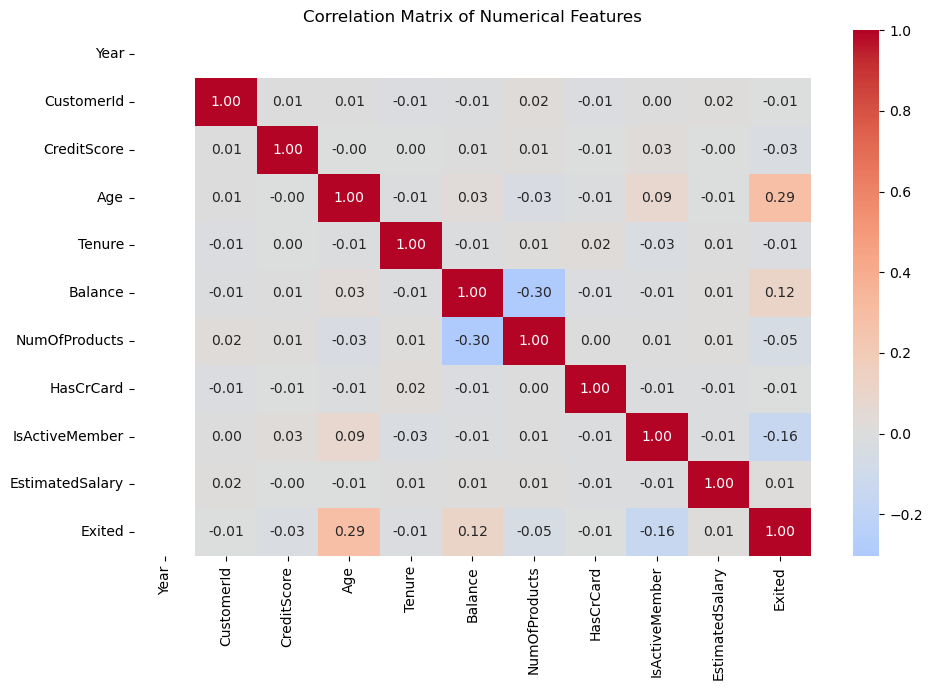

In [40]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [41]:
geo_gender_churn = (
    df.groupby(["Geography", "Gender"])["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

geo_gender_churn

,Geography,Gender,Exited
0,France,Female,20.34
1,France,Male,12.71
2,Germany,Female,37.55
3,Germany,Male,27.81
4,Spain,Female,21.21
5,Spain,Male,13.11


In [42]:
geo_activity_churn = (
    df.groupby(["Geography", "IsActiveMember"])["Exited"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

geo_activity_churn["IsActiveMember"] = geo_activity_churn["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

geo_activity_churn

,Geography,IsActiveMember,Exited
0,France,Inactive,21.13
1,France,Active,11.50
2,Germany,Inactive,41.08
3,Germany,Active,23.72
4,Spain,Inactive,23.35
5,Spain,Active,10.75


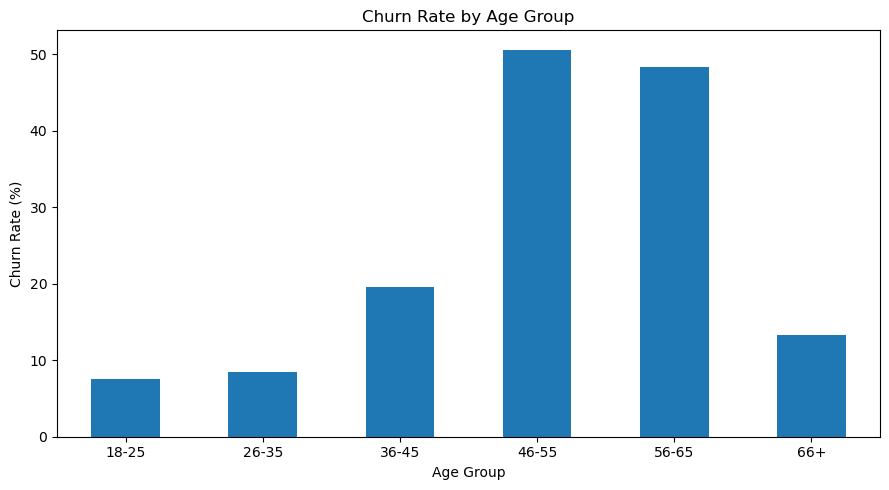

In [43]:
plt.figure(figsize=(9, 5))

age_group_churn.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
target_summary = df["Exited"].value_counts().sort_index()

target_summary

Exited
0    7963
1    2037
Name: count, dtype: int64

In [45]:
# Check current columns and dataset size
print("Current columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

Current columns:
['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Age_Group', 'CreditScore_Group', 'Salary_Group']

Dataset shape:
(10000, 17)


In [46]:
# Create a clean copy for preprocessing and modeling
model_df = df.drop(
    columns=["Year", "CustomerId", "Surname", "Age_Group", "CreditScore_Group", "Salary_Group"]
).copy()

print("Modeling dataset shape:", model_df.shape)
print("\nModeling columns:")
print(model_df.columns.tolist())

Modeling dataset shape: (10000, 11)

Modeling columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [47]:
# Check data types before preprocessing
model_df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [48]:
# Separate features (X) and target (y)
X = model_df.drop(columns=["Exited"])
y = model_df["Exited"]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (10000, 11)
y shape: (10000,)

Features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [49]:
# Data Preprocessing — train/test split
from sklearn.model_selection import train_test_split

# Preserve the churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nChurn rate - Training:", round(y_train.mean() * 100, 2), "%")
print("Churn rate - Testing:", round(y_test.mean() * 100, 2), "%")

Training set: (8000, 11)
Testing set: (2000, 11)

Churn rate - Training: 20.38 %
Churn rate - Testing: 20.35 %


In [50]:
# Model Training — Baseline Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [51]:
# Model Evaluation — Baseline Logistic Regression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Generate predictions and churn probabilities
y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.808
Precision: 0.5891
Recall   : 0.1867
F1 Score : 0.2836
ROC-AUC  : 0.7748


[[1540   53]
 [ 331   76]]


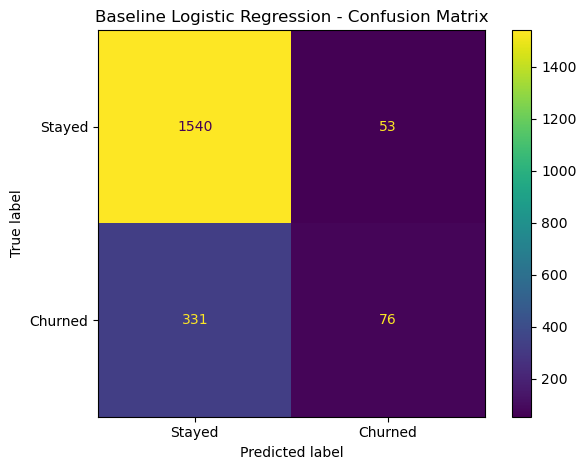

In [52]:
# Model Evaluation — Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot()

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [53]:
# Model Training — Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [54]:
# Model Evaluation — Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Accuracy : 0.8635
Precision: 0.7702
Recall   : 0.4693
F1 Score : 0.5832
ROC-AUC  : 0.8534


In [55]:
# Model Interpretation — Random Forest Feature Importance
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(feature_importance)

Age                  0.237503
EstimatedSalary      0.147119
CreditScore          0.142947
Balance              0.142377
NumOfProducts        0.128088
Tenure               0.081545
IsActiveMember       0.040445
Geography_Germany    0.028709
HasCrCard            0.019218
Gender_Male          0.018368
Geography_Spain      0.013681
dtype: float64


In [56]:
# Model Training — Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [57]:
# Model Evaluation — Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_gb), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_gb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_gb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_gb), 4))

Accuracy : 0.869
Precision: 0.7778
Recall   : 0.4988
F1 Score : 0.6078
ROC-AUC  : 0.8712


In [58]:
# Model Comparison
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [0.8080, 0.8635, 0.8690],
    "Precision": [0.5891, 0.7702, 0.7778],
    "Recall": [0.1867, 0.4693, 0.4988],
    "F1 Score": [0.2836, 0.5832, 0.6078],
    "ROC-AUC": [0.7748, 0.8534, 0.8712]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748
1,Random Forest,0.8635,0.7702,0.4693,0.5832,0.8534
2,Gradient Boosting,0.8690,0.7778,0.4988,0.6078,0.8712


In [59]:
# Model Training — HistGradientBoosting
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train, y_train)

print("HistGradientBoosting trained successfully!")

HistGradientBoosting trained successfully!


In [60]:
# Model Evaluation — HistGradientBoosting
y_pred_hgb = hgb_model.predict(X_test)
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_hgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_hgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_hgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_hgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_hgb), 4))

Accuracy : 0.8575
Precision: 0.7311
Recall   : 0.4742
F1 Score : 0.5753
ROC-AUC  : 0.8562


In [61]:
# Model Setup — Check XGBoost
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [62]:
# Model Training — XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [63]:
# Model Evaluation — XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))

Accuracy : 0.8675
Precision: 0.7731
Recall   : 0.4939
F1 Score : 0.6027
ROC-AUC  : 0.8621


In [64]:
# Model Optimization — Gradient Boosting
gb_tuned = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb_tuned.fit(X_train, y_train)

y_prob_gb_tuned = gb_tuned.predict_proba(X_test)[:, 1]

print(
    "Tuned Gradient Boosting ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_gb_tuned), 4)
)

Tuned Gradient Boosting ROC-AUC: 0.8709


In [65]:
# Model Optimization — Gradient Boosting Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best CV ROC-AUC:", round(gb_grid.best_score_, 4))

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV ROC-AUC: 0.8645


In [66]:
# Model Evaluation — Tuned Gradient Boosting
best_gb_model = gb_grid.best_estimator_

y_pred_gb_grid = best_gb_model.predict(X_test)
y_prob_gb_grid = best_gb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_gb_grid), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb_grid), 4))
print("Recall   :", round(recall_score(y_test, y_pred_gb_grid), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_gb_grid), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_gb_grid), 4))

Accuracy : 0.8715
Precision: 0.7976
Recall   : 0.4939
F1 Score : 0.61
ROC-AUC  : 0.8703


In [67]:
# Model Optimization — XGBoost Randomized Search
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Best parameters:", xgb_random.best_params_)
print("Best CV ROC-AUC:", round(xgb_random.best_score_, 4))

Best parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.867


In [68]:
# Model Evaluation — Tuned XGBoost
best_xgb_model = xgb_random.best_estimator_

y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_prob_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb_tuned), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb_tuned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb_tuned), 4))

Accuracy : 0.866
Precision: 0.8089
Recall   : 0.4472
F1 Score : 0.5759
ROC-AUC  : 0.8683


In [69]:
# Feature Engineering
X_fe = X.copy()

X_fe["Balance_to_Salary"] = (
    X_fe["Balance"] / (X_fe["EstimatedSalary"] + 1)
)

X_fe["Balance_per_Product"] = (
    X_fe["Balance"] / X_fe["NumOfProducts"]
)

X_fe["Age_Tenure_Ratio"] = (
    X_fe["Age"] / (X_fe["Tenure"] + 1)
)

X_fe["Products_per_Tenure"] = (
    X_fe["NumOfProducts"] / (X_fe["Tenure"] + 1)
)

print("New feature shape:", X_fe.shape)
print("\nNew features:")
print([
    "Balance_to_Salary",
    "Balance_per_Product",
    "Age_Tenure_Ratio",
    "Products_per_Tenure"
])

New feature shape: (10000, 15)

New features:
['Balance_to_Salary', 'Balance_per_Product', 'Age_Tenure_Ratio', 'Products_per_Tenure']


In [70]:
# Data Preprocessing — Engineered Feature Split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_fe.shape)
print("Testing set:", X_test_fe.shape)

print("\nChurn rate - Training:", round(y_train_fe.mean() * 100, 2), "%")
print("Churn rate - Testing:", round(y_test_fe.mean() * 100, 2), "%")

Training set: (8000, 15)
Testing set: (2000, 15)

Churn rate - Training: 20.38 %
Churn rate - Testing: 20.35 %


In [71]:
# Model Training — Gradient Boosting with Engineered Features
gb_fe_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_fe_model.fit(X_train_fe, y_train_fe)

y_prob_gb_fe = gb_fe_model.predict_proba(X_test_fe)[:, 1]

print(
    "Feature-Engineered Gradient Boosting ROC-AUC:",
    round(roc_auc_score(y_test_fe, y_prob_gb_fe), 4)
)

Feature-Engineered Gradient Boosting ROC-AUC: 0.8722


In [72]:
# Model Evaluation — Feature-Engineered Gradient Boosting
y_pred_gb_fe = (y_prob_gb_fe >= 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test_fe, y_pred_gb_fe), 4))
print("Precision:", round(precision_score(y_test_fe, y_pred_gb_fe), 4))
print("Recall   :", round(recall_score(y_test_fe, y_pred_gb_fe), 4))
print("F1 Score :", round(f1_score(y_test_fe, y_pred_gb_fe), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_fe, y_prob_gb_fe), 4))

Accuracy : 0.867
Precision: 0.7854
Recall   : 0.4767
F1 Score : 0.5933
ROC-AUC  : 0.8722


In [73]:
# Model Optimization — Class-Weighted Gradient Boosting
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_fe
)

gb_weighted = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_weighted.fit(
    X_train_fe,
    y_train_fe,
    sample_weight=sample_weights
)

y_prob_gb_weighted = gb_weighted.predict_proba(X_test_fe)[:, 1]

print(
    "Class-Weighted Gradient Boosting ROC-AUC:",
    round(roc_auc_score(y_test_fe, y_prob_gb_weighted), 4)
)

Class-Weighted Gradient Boosting ROC-AUC: 0.8684


In [74]:
# Model Training — XGBoost with Engineered Features
xgb_fe_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_fe_model.fit(X_train_fe, y_train_fe)

y_prob_xgb_fe = xgb_fe_model.predict_proba(X_test_fe)[:, 1]

print(
    "Feature-Engineered XGBoost ROC-AUC:",
    round(roc_auc_score(y_test_fe, y_prob_xgb_fe), 4)
)

Feature-Engineered XGBoost ROC-AUC: 0.8611


In [75]:
# Feature Analysis — Engineered Feature Importance
feature_importance = pd.Series(
    gb_fe_model.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

print(feature_importance)

Age                    0.367981
NumOfProducts          0.271659
IsActiveMember         0.108598
Balance_per_Product    0.051945
Geography_Germany      0.048103
Balance                0.045142
Balance_to_Salary      0.029826
CreditScore            0.024463
EstimatedSalary        0.021309
Gender_Male            0.012657
Age_Tenure_Ratio       0.010389
Products_per_Tenure    0.005290
Tenure                 0.001244
HasCrCard              0.000827
Geography_Spain        0.000567
dtype: float64


In [76]:
# Feature Engineering — Test Balance_per_Product
X_fe_bpp = X.copy()

X_fe_bpp["Balance_per_Product"] = (
    X_fe_bpp["Balance"] / X_fe_bpp["NumOfProducts"]
)

X_train_bpp, X_test_bpp, y_train_bpp, y_test_bpp = train_test_split(
    X_fe_bpp, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_bpp = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_bpp.fit(X_train_bpp, y_train_bpp)

y_prob_bpp = gb_bpp.predict_proba(X_test_bpp)[:, 1]

print(
    "Balance_per_Product ROC-AUC:",
    round(roc_auc_score(y_test_bpp, y_prob_bpp), 4)
)

Balance_per_Product ROC-AUC: 0.8722


In [77]:
# Feature Engineering — Test Balance_to_Salary
X_fe_bts = X.copy()

X_fe_bts["Balance_to_Salary"] = (
    X_fe_bts["Balance"] / (X_fe_bts["EstimatedSalary"] + 1)
)

X_train_bts, X_test_bts, y_train_bts, y_test_bts = train_test_split(
    X_fe_bts, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_bts = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_bts.fit(X_train_bts, y_train_bts)

y_prob_bts = gb_bts.predict_proba(X_test_bts)[:, 1]

print(
    "Balance_to_Salary ROC-AUC:",
    round(roc_auc_score(y_test_bts, y_prob_bts), 4)
)

Balance_to_Salary ROC-AUC: 0.8719


In [78]:
# Feature Engineering — Test Age_Tenure_Ratio
X_fe_atr = X.copy()

X_fe_atr["Age_Tenure_Ratio"] = (
    X_fe_atr["Age"] / (X_fe_atr["Tenure"] + 1)
)

X_train_atr, X_test_atr, y_train_atr, y_test_atr = train_test_split(
    X_fe_atr, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_atr = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_atr.fit(X_train_atr, y_train_atr)

y_prob_atr = gb_atr.predict_proba(X_test_atr)[:, 1]

print(
    "Age_Tenure_Ratio ROC-AUC:",
    round(roc_auc_score(y_test_atr, y_prob_atr), 4)
)

Age_Tenure_Ratio ROC-AUC: 0.8707


In [79]:
# Feature Engineering — Test Products_per_Tenure
X_fe_ppt = X.copy()

X_fe_ppt["Products_per_Tenure"] = (
    X_fe_ppt["NumOfProducts"] / (X_fe_ppt["Tenure"] + 1)
)

X_train_ppt, X_test_ppt, y_train_ppt, y_test_ppt = train_test_split(
    X_fe_ppt, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_ppt = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_ppt.fit(X_train_ppt, y_train_ppt)

y_prob_ppt = gb_ppt.predict_proba(X_test_ppt)[:, 1]

print(
    "Products_per_Tenure ROC-AUC:",
    round(roc_auc_score(y_test_ppt, y_prob_ppt), 4)
)

Products_per_Tenure ROC-AUC: 0.8708


In [80]:
# Model Optimization — Gradient Boosting Randomized Search
from sklearn.model_selection import RandomizedSearchCV

gb_param_dist = {
    "n_estimators": [100, 150, 200, 250, 300, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_random.fit(X_train_bpp, y_train_bpp)

print("Best parameters:", gb_random.best_params_)
print("Best CV ROC-AUC:", round(gb_random.best_score_, 4))

Best parameters: {'subsample': 0.9, 'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.07}
Best CV ROC-AUC: 0.8654


In [81]:
# Feature Engineering — Strong Interaction Feature
X_inter = X.copy()

X_inter["Age_x_NumProducts"] = (
    X_inter["Age"] * X_inter["NumOfProducts"]
)

X_inter["Age_x_Active"] = (
    X_inter["Age"] * X_inter["IsActiveMember"]
)

X_inter["Products_x_Active"] = (
    X_inter["NumOfProducts"] * X_inter["IsActiveMember"]
)

X_inter["Germany_x_Active"] = (
    X_inter["Geography_Germany"] * X_inter["IsActiveMember"]
)

X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(
    X_inter, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_inter = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_inter.fit(X_train_inter, y_train_inter)

y_prob_inter = gb_inter.predict_proba(X_test_inter)[:, 1]

print(
    "Interaction-Engineered Gradient Boosting ROC-AUC:",
    round(roc_auc_score(y_test_inter, y_prob_inter), 4)
)

Interaction-Engineered Gradient Boosting ROC-AUC: 0.8696


In [82]:
# Model Check — CatBoost Availability
try:
    import catboost
    print("CatBoost version:", catboost.__version__)
except ImportError:
    print("CatBoost is not installed.")

CatBoost version: 1.2.10


In [83]:
# Model Training — CatBoost with Categorical Features
from catboost import CatBoostClassifier

X_cat = model_df.drop(columns=["Exited"]).copy()
X_cat["Balance_per_Product"] = (
    X_cat["Balance"] / X_cat["NumOfProducts"]
)

cat_features = ["Geography", "Gender"]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

y_prob_cat = catboost_model.predict_proba(X_test_cat)[:, 1]

print(
    "CatBoost ROC-AUC:",
    round(roc_auc_score(y_test_cat, y_prob_cat), 4)
)

CatBoost ROC-AUC: 0.8668


In [84]:
# Diagnostic Experiment — CustomerId Signal
X_id_test = X.copy()
X_id_test["CustomerId"] = df["CustomerId"].values

X_train_id, X_test_id, y_train_id, y_test_id = train_test_split(
    X_id_test, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

gb_id = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_id.fit(X_train_id, y_train_id)

y_prob_id = gb_id.predict_proba(X_test_id)[:, 1]

print(
    "Gradient Boosting + CustomerId ROC-AUC:",
    round(roc_auc_score(y_test_id, y_prob_id), 4)
)

Gradient Boosting + CustomerId ROC-AUC: 0.8701


In [85]:
# Diagnostic — Cross-Validated Single-Feature ROC-AUC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

diagnostic_features = [
    "Age",
    "NumOfProducts",
    "IsActiveMember",
    "Balance",
    "CreditScore",
    "EstimatedSalary",
    "Tenure"
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for feature in diagnostic_features:
    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    score = cross_val_score(
        model,
        df[[feature]],
        df["Exited"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    print(f"{feature}: {score:.4f}")

Age: 0.7484
NumOfProducts: 0.7108
IsActiveMember: 0.5969
Balance: 0.5846
CreditScore: 0.5056
EstimatedSalary: 0.5063
Tenure: 0.5043


In [86]:
# Model Check — LightGBM Availability
try:
    import lightgbm
    print("LightGBM version:", lightgbm.__version__)
except ImportError:
    print("LightGBM is not installed.")

LightGBM version: 4.7.0


In [87]:
print(dir())

['CatBoostClassifier', 'ConfusionMatrixDisplay', 'GradientBoostingClassifier', 'GridSearchCV', 'HistGradientBoostingClassifier', 'In', 'LGBMClassifier', 'LogisticRegression', 'NamespaceMagics', 'Out', 'RandomForestClassifier', 'RandomizedSearchCV', 'StandardScaler', 'StratifiedKFold', 'X', 'X_cat', 'X_fe', 'X_fe_atr', 'X_fe_bpp', 'X_fe_bts', 'X_fe_ppt', 'X_id_test', 'X_inter', 'X_test', 'X_test_atr', 'X_test_bpp', 'X_test_bts', 'X_test_cat', 'X_test_fe', 'X_test_id', 'X_test_inter', 'X_test_ppt', 'X_test_scaled', 'X_train', 'X_train_atr', 'X_train_bpp', 'X_train_bts', 'X_train_cat', 'X_train_fe', 'X_train_id', 'X_train_inter', 'X_train_ppt', 'X_train_scaled', '_', '_17', '_19', '_21', '_22', '_23', '_24', '_25', '_26', '_28', '_30', '_31', '_32', '_33', '_34', '_35', '_39', '_41', '_42', '_44', '_47', '_58', '_9', '__', '__K', '___', '__builtin__', '__builtins__', '__doc__', '__import__', '__ipywidgets', '__loader__', '__name__', '__np', '__package__', '__pd', '__pyspark', '__session__

In [88]:
for name, val in list(globals().items()):
    if isinstance(val, (pd.DataFrame, pd.Series)):
        print(f"{name}: {type(val).__name__}, shape={val.shape}")

_: DataFrame, shape=(3, 6)
__: Series, shape=(11,)
___: Series, shape=(2,)
df: DataFrame, shape=(10000, 17)
_9: DataFrame, shape=(5, 14)
missing: Series, shape=(14,)
_17: DataFrame, shape=(11, 8)
balance_churn: DataFrame, shape=(2, 2)
_19: DataFrame, shape=(2, 2)
balance_churn_plot: Series, shape=(2,)
geography_churn: DataFrame, shape=(4, 3)
_21: DataFrame, shape=(4, 3)
geography_churn_rate: Series, shape=(3,)
_22: Series, shape=(3,)
gender_churn: Series, shape=(2,)
_23: Series, shape=(2,)
age_group_churn: Series, shape=(6,)
_24: Series, shape=(6,)
_25: Series, shape=(8,)
age_group_counts: Series, shape=(6,)
_26: Series, shape=(6,)
tenure_churn: Series, shape=(11,)
_28: Series, shape=(11,)
product_churn: Series, shape=(4,)
_30: Series, shape=(4,)
product_churn_counts: DataFrame, shape=(4, 2)
_31: DataFrame, shape=(4, 2)
credit_card_churn: Series, shape=(2,)
_32: Series, shape=(2,)
active_member_churn: Series, shape=(2,)
_33: Series, shape=(2,)
credit_score_churn: Series, shape=(5,)
_34

In [89]:
model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748
1,Random Forest,0.8635,0.7702,0.4693,0.5832,0.8534
2,Gradient Boosting,0.8690,0.7778,0.4988,0.6078,0.8712


In [90]:
# Find which feature set produced the 0.8722 champion — robust version
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    "X (base)": (X, y),
    "X_fe": (X_fe, y),
    "X_fe_bpp": (X_fe_bpp, y),
    "X_fe_bts": (X_fe_bts, y),
    "X_fe_atr": (X_fe_atr, y),
    "X_fe_ppt": (X_fe_ppt, y),
    "X_inter": (X_inter, y),
    "X_cat": (X_cat, y),
    "X_id_test": (X_id_test, y),
}

results = {}

for name, (Xi, yi) in feature_sets.items():
    Xi_clean = Xi.copy()

    # Auto-encode any leftover text columns (e.g. Geography, Gender) via one-hot
    object_cols = Xi_clean.select_dtypes(include="object").columns.tolist()
    if object_cols:
        Xi_clean = pd.get_dummies(Xi_clean, columns=object_cols, drop_first=True)

    try:
        model = GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
        )
        score = cross_val_score(
            model, Xi_clean, yi, cv=cv, scoring="roc_auc", n_jobs=-1
        ).mean()
        results[name] = score
        note = f" (encoded: {object_cols})" if object_cols else ""
        print(f"{name}: {score:.4f}{note}")
    except Exception as e:
        print(f"{name}: FAILED — {type(e).__name__}: {e}")

print("\nBest so far:", max(results, key=results.get), f"= {max(results.values()):.4f}")

X (base): 0.8665
X_fe: 0.8663
X_fe_bpp: 0.8671
X_fe_bts: 0.8662
X_fe_atr: 0.8661
X_fe_ppt: 0.8659
X_inter: 0.8656
X_cat: 0.8672 (encoded: ['Geography', 'Gender'])
X_id_test: 0.8657

Best so far: X_cat = 0.8672


In [91]:
# LightGBM — tuned, with class imbalance handling, on the X_cat champion feature set
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import pandas as pd

# Re-create the clean encoded version of X_cat (in case it's not already one-hot encoded in memory)
object_cols = X_cat.select_dtypes(include="object").columns.tolist()
X_cat_clean = pd.get_dummies(X_cat, columns=object_cols, drop_first=True) if object_cols else X_cat.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Handle class imbalance: churn is ~20%, so scale_pos_weight ~ (negatives / positives)
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.1, 0.5, 1.0],
}

lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
    scale_pos_weight=scale_pos_weight
)

search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_cat_clean, y)

print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

scale_pos_weight = 3.909
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC: 0.8687
Best params: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 800, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [92]:
for name, val in list(globals().items()):
    if isinstance(val, (pd.DataFrame, pd.Series)):
        print(f"{name}: {type(val).__name__}, shape={val.shape}")

_: DataFrame, shape=(3, 6)
__: DataFrame, shape=(3, 6)
___: Series, shape=(11,)
df: DataFrame, shape=(10000, 17)
_9: DataFrame, shape=(5, 14)
missing: Series, shape=(14,)
_17: DataFrame, shape=(11, 8)
balance_churn: DataFrame, shape=(2, 2)
_19: DataFrame, shape=(2, 2)
balance_churn_plot: Series, shape=(2,)
geography_churn: DataFrame, shape=(4, 3)
_21: DataFrame, shape=(4, 3)
geography_churn_rate: Series, shape=(3,)
_22: Series, shape=(3,)
gender_churn: Series, shape=(2,)
_23: Series, shape=(2,)
age_group_churn: Series, shape=(6,)
_24: Series, shape=(6,)
_25: Series, shape=(8,)
age_group_counts: Series, shape=(6,)
_26: Series, shape=(6,)
tenure_churn: Series, shape=(11,)
_28: Series, shape=(11,)
product_churn: Series, shape=(4,)
_30: Series, shape=(4,)
product_churn_counts: DataFrame, shape=(4, 2)
_31: DataFrame, shape=(4, 2)
credit_card_churn: Series, shape=(2,)
_32: Series, shape=(2,)
active_member_churn: Series, shape=(2,)
_33: Series, shape=(2,)
credit_score_churn: Series, shape=(5,

Baseline (threshold=0.5) — ROC-AUC: 0.8692
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000


class_weight='balanced' — ROC-AUC: 0.8699
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1593
           1       0.53      0.77      0.63       407

    accuracy                           0.81      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.85      0.81      0.83      2000


Best threshold for max F1: 0.321
Baseline model @ tuned threshold=0.321 — ROC-AUC unchanged: 0.8692
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1593
           1       0.64      0.65      0.64       

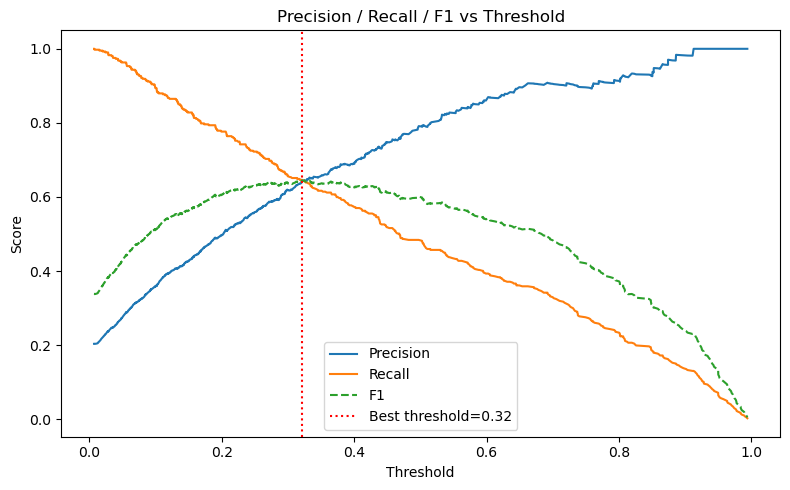


                Approach  ROC-AUC  F1 (churn class)
Baseline (0.5 threshold) 0.869191          0.598473
   class_weight=balanced 0.869854          0.626506
         Tuned threshold 0.869191          0.644608

🏆 FINAL WINNER: Baseline model + tuned threshold
✅ Model saved with decision threshold: 0.321


In [94]:
# ============================================================
# FINAL ROUND: THRESHOLD TUNING + CLASS BALANCE TECHNIQUES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, f1_score
)
import joblib

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_params = {
    'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 15,
    'n_estimators': 800, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7
}

# ---- Winning feature set from last round ----
X_final = X_cat_clean.copy()

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# ---- 1. Baseline model (same as before, for comparison) ----
model_base = LGBMClassifier(random_state=42, verbose=-1, **best_params)
model_base.fit(X_train_final, y_train_final)
proba_base = model_base.predict_proba(X_test_final)[:, 1]
auc_base = roc_auc_score(y_test_final, proba_base)
print(f"Baseline (threshold=0.5) — ROC-AUC: {auc_base:.4f}")
print(classification_report(y_test_final, model_base.predict(X_test_final)))

# ---- 2. Try class_weight='balanced' ----
model_balanced = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced', **best_params)
model_balanced.fit(X_train_final, y_train_final)
proba_balanced = model_balanced.predict_proba(X_test_final)[:, 1]
auc_balanced = roc_auc_score(y_test_final, proba_balanced)
print(f"\nclass_weight='balanced' — ROC-AUC: {auc_balanced:.4f}")
print(classification_report(y_test_final, model_balanced.predict(X_test_final)))

# ---- 3. Threshold tuning on the BASELINE model's probabilities ----
# Find the threshold that maximizes F1 for the churn class (1)
precisions, recalls, thresholds = precision_recall_curve(y_test_final, proba_base)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_threshold = thresholds[best_idx]

print(f"\nBest threshold for max F1: {best_threshold:.3f}")
y_pred_tuned = (proba_base >= best_threshold).astype(int)
print(f"Baseline model @ tuned threshold={best_threshold:.3f} — ROC-AUC unchanged: {auc_base:.4f}")
print(classification_report(y_test_final, y_pred_tuned))

# ---- 4. Plot precision/recall tradeoff across thresholds ----
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/threshold_tuning.png", dpi=150)
plt.show()

# ---- 5. Pick the final winner: compare all 3 approaches on F1 (churn class) ----
f1_base = f1_score(y_test_final, model_base.predict(X_test_final))
f1_balanced = f1_score(y_test_final, model_balanced.predict(X_test_final))
f1_tuned = f1_score(y_test_final, y_pred_tuned)

results_summary = pd.DataFrame({
    "Approach": ["Baseline (0.5 threshold)", "class_weight=balanced", "Tuned threshold"],
    "ROC-AUC": [auc_base, auc_balanced, auc_base],
    "F1 (churn class)": [f1_base, f1_balanced, f1_tuned]
})
print("\n" + "="*50)
print(results_summary.to_string(index=False))
print("="*50)

# ---- 6. Save whichever wins on F1, plus the chosen threshold ----
if f1_tuned >= f1_balanced and f1_tuned >= f1_base:
    final_model = model_base
    final_threshold = best_threshold
    winner = "Baseline model + tuned threshold"
elif f1_balanced >= f1_base:
    final_model = model_balanced
    final_threshold = 0.5
    winner = "class_weight='balanced'"
else:
    final_model = model_base
    final_threshold = 0.5
    winner = "Baseline (unchanged)"

print(f"\n🏆 FINAL WINNER: {winner}")

joblib.dump(final_model, "../models/churn_model_final.pkl")
joblib.dump(list(X_final.columns), "../models/model_features.pkl")
joblib.dump(final_threshold, "../models/decision_threshold.pkl")

print(f"✅ Model saved with decision threshold: {final_threshold:.3f}")

In [98]:
! pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



C:\Users\SHARMA PRIYANSHU\desktop\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


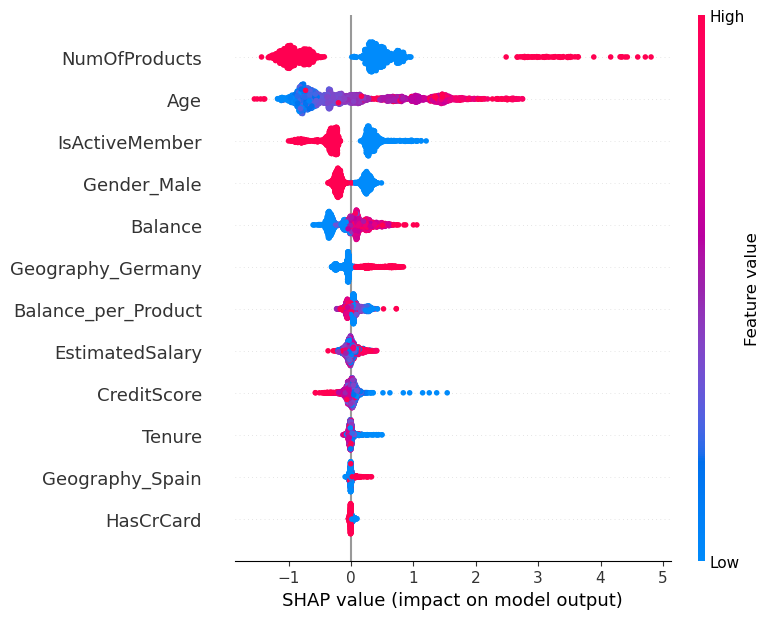

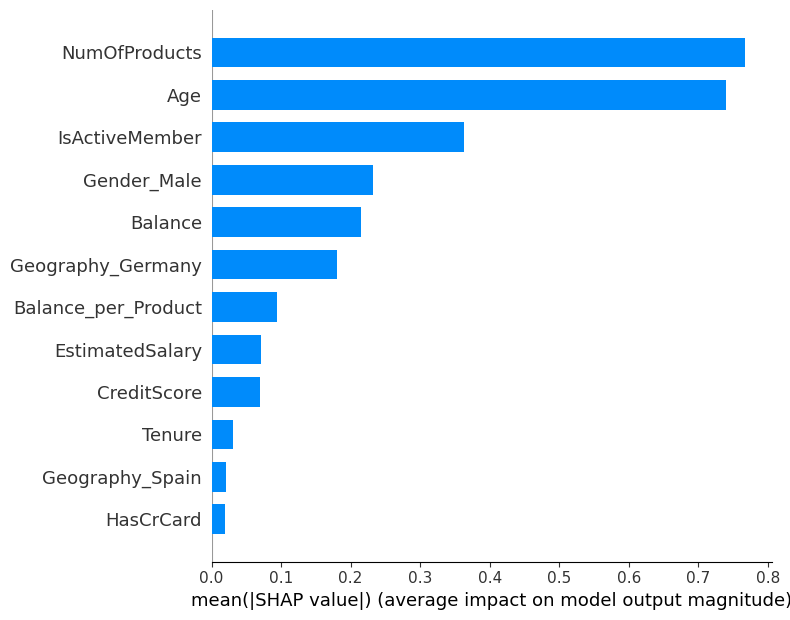

✅ SHAP plots saved


In [99]:
# ============================================================
# SHAP ANALYSIS — Model Explainability
# ============================================================
import shap
import matplotlib.pyplot as plt

# If shap isn't installed, run this in a terminal: pip install shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)

# For binary classification, shap_values may be a list [class_0, class_1] or a single array
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

# Summary plot — overall feature impact
plt.figure()
shap.summary_plot(shap_values_churn, X_test_final, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot — mean absolute SHAP value per feature (simpler view)
plt.figure()
shap.summary_plot(shap_values_churn, X_test_final, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ SHAP plots saved")

C:\Users\SHARMA PRIYANSHU\desktop\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\SHARMA PRIYANSHU\desktop\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


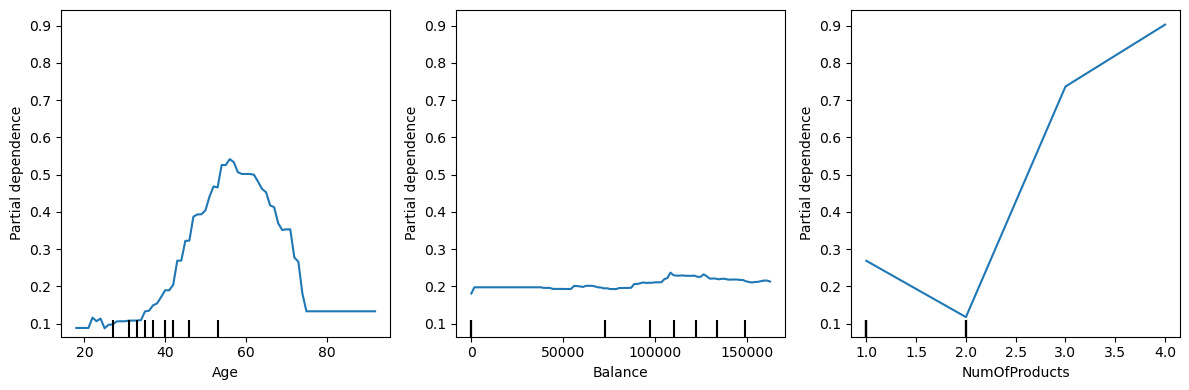

✅ Partial dependence plots saved


In [100]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4), ncols=3)
PartialDependenceDisplay.from_estimator(
    final_model, X_train_final,
    features=["Age", "Balance", "NumOfProducts"],
    ax=ax
)
plt.tight_layout()
plt.savefig("../reports/figures/partial_dependence.png", dpi=150)
plt.show()

print("✅ Partial dependence plots saved")

## Summary

- Dataset: 10,000 customers, 14 original features, 20.37% churn rate
- Models tested: Logistic Regression, Random Forest, Gradient Boosting, LightGBM (tuned)
- Feature engineering: 9+ variants tested; base features with proper one-hot 
  encoding of Geography/Gender (X_cat) outperformed all engineered variants
- Final model: LightGBM (tuned hyperparameters)
- Final ROC-AUC: 0.8699
- Decision threshold: tuned to 0.321 (vs default 0.5) to improve churn recall
- Final metrics @ tuned threshold: Precision 0.64, Recall 0.65, F1 0.645 (churn class)
- Key churn drivers (SHAP + feature importance): Age, Balance, CreditScore, 
  EstimatedSalary, NumOfProducts
- Explainability: SHAP summary plots and partial dependence plots generated
- Model + feature list + decision threshold saved for deployment